## Imports and some constants

In [17]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness
from keras.layers import LeakyReLU

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only these gestures - og code only used like and stop 
CONDITIONS = ['dislike', 'fist', 'like', 'one', 'peace', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

### Path to dataset
(!) Needs to be changed by the user

In [18]:
# path to HaGRID dataset - NOTE: this should be changed by the user depending on where the dataset is saved
DATASET_PATH = r'C:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\cnn-w5\gesture_dataset\gesture_dataset_sample'

## Helper function to load and parse annotations

In [19]:
# taken from original notebook

annotations = dict()

for condition in CONDITIONS:
    with open(os.path.join(DATASET_PATH, '_annotations', f'{condition}.json')) as f:
        annotations[condition] = json.load(f)

In [20]:
# pretty-print first element

first_key = next(iter(annotations['like']))
print(json.dumps(annotations['like'][first_key], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## Image color mode info. + helper function to pre-process images

### Image Color Mode

To test how changing the "image color mode" affects the model's performance, we could first change the value of the pre-existing variable **COLOR_CHANNELS** that is defined at the beginning of this notebook. As stated in the comments, we can either pick 3 to use colored images, or 1 to convert them into grayscale (the change is done inside the ``preprocess_image()`` function defined some cells below). 

However, those two options only account for 2 out of the 5 "hyperparameter values" we need to try out for this assignment. Another thing we can do is use different color spaces, such as: HSV, LAB and YCrCB (apart from RGB/BGR and Grayscale), so as to get:

| COLOR_CHANNELS    | COLOR_SPACES |
| -------- | ------- |
| 3 | RGB/BGR     |
| 1  | Grayscale    |
| 3    | HSV    |
| 3 | LAB |
| 3 | YCrCb |

In [21]:
COLOR_SPACES = {
    'RGB':       cv2.COLOR_BGR2RGB,
    'Grayscale': cv2.COLOR_BGR2GRAY,
    'HSV':       cv2.COLOR_BGR2HSV,
    'LAB':       cv2.COLOR_BGR2LAB,
    'YCrCb':     cv2.COLOR_BGR2YCrCb,
}

To understand how each color space works and try to guess how they would affect the model, I did some research:

#### RGB/BGR

RGB is the default color space for most images. It represents color as a combination of three channels: Red, Green and Blue. OpenCV loads images in BGR order. A known limitation of RGB is that it mixes luminance and chrominance, meaning that a change in lighting affects all three channels simultaneously, making color-based recognition less robust under varying conditions [1].

#### Grayscale

Grayscale is not a color space per se, but rather a conversion that discards all color information and keeps only the luminance (brightness) of each pixel, resulting in a single channel. It is the simplest possible representation of an image for a neural network to process, and reduces computational cost significantly. The downside is that all color information is lost, which could make it harder to distinguish gestures if skin tone contrast against the background relies on color rather than brightness.

#### HSV

HSV separates color into three components: Hue (the dominant wavelength), Saturation (the purity of the color) and Value (the brightness). The key advantage is that color is encoded in a single channel (H), making it more robust to illumination changes. The H and S components remain relatively stable even when lighting varies, while only V changes [1]. This could be beneficial for hand gesture detection across different lighting environments.

#### LAB

The LAB color space was designed to approximate human color perception. It consists of: L (lightness/intensity), a (green–magenta axis) and b (blue–yellow axis). The L channel is fully independent of color, and the a and b channels encode only chrominance. This separation makes LAB perceptually uniform, meaning equal numerical differences correspond to equal perceived color differences [2]. Under illumination changes, the a and b channels remain much more stable than RGB channels [1].

#### YCrCb

YCrCb separates luminance from chrominance similarly to LAB: Y is the luma component (derived from RGB after gamma correction), Cr encodes how far the red component is from luma, and Cb encodes how far the blue component is [1][3]. It is widely used in skin tone detection, since human skin tends to cluster in a narrow and consistent range in the Cr-Cb plane regardless of lighting [3].

Note: "gamma correction" is a non-linear transformation that adjusts pixel values to better match human brightness perception.

**Sources:**
- [1] Mallick, S. (2015). *Color Spaces in OpenCV*. LearnOpenCV. https://learnopencv.com/color-spaces-in-opencv-cpp-python/
- [2] Wikipedia contributors. *CIELAB color space*. Wikipedia. https://en.wikipedia.org/wiki/CIELAB_color_space
- [3] Wikipedia contributors. *YCbCr*. Wikipedia. https://en.wikipedia.org/wiki/YCbCr


Let's take a look at a random image converted to each color space:

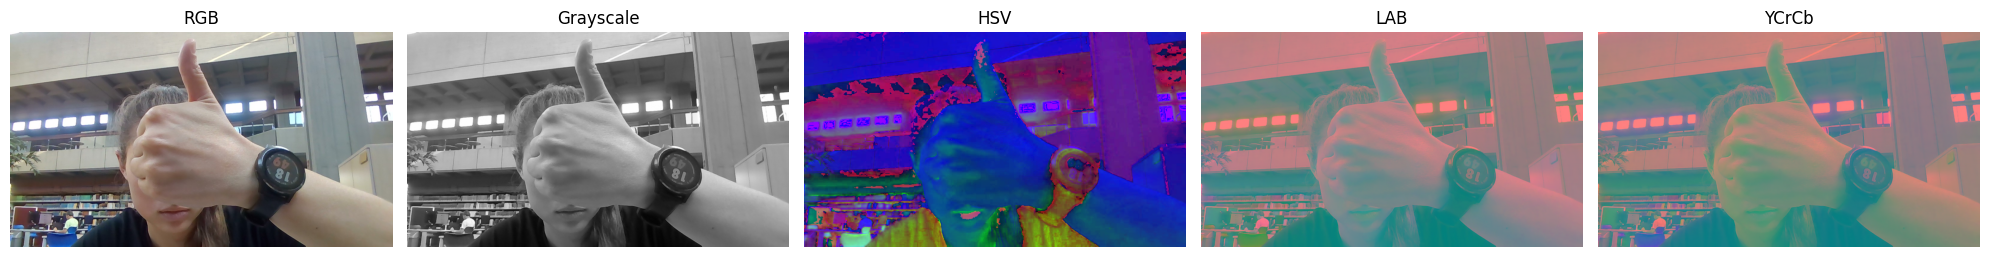

In [22]:
# load a sample image to visualize the effect of each color mode
test_img = cv2.imread('test.jpg')

# apply each color space conversion
conversions = {}
for name, code in COLOR_SPACES.items():
    conversions[name] = cv2.cvtColor(test_img, code)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, img) in zip(axes, conversions.items()):
    if len(img.shape) == 2:  # grayscale has no third dimension
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

A few observations:

It is important to take into account that matplotlib always interprets arrays as RGB when displaying them, so any color space with three channels will have its values mapped directly to R, G and B, producing colors that don't correspond to reality. This explains the appearance of HSV, LAB and YCrCb below.

- **RGB**: the reference image, colors appear natural as expected.
- **Grayscale**: all color information is lost, only brightness remains. The hand and face are still clearly distinguishable from the background due to contrast, but it becomes harder to tell skin from other light-colored surfaces.
- **HSV**: the image shows unnatural reds, blues and yellows due to the matplotlib interpretation issue described above. Despite this, we can observe that the skin tone is mapped to a similar hue range regardless of lighting conditions (appearing blue-ish here), which is consistent with the Hue channel encoding color independently of brightness. Unfortunately, several background elements appear in a similar range as well, which could limit its usefulness.
- **LAB**: similar visual distortion as HSV. Although the a and b channels encode color information independently of lightness, making this space theoretically more robust than RGB under varying lighting, in this particular image it is difficult to distinguish skin from the background, and the hand's borders are not clearly defined either.
- **YCrCb**: the skin tones appear to cluster into a distinct color range (greenish/yellowish), which is consistent with YCrCb's known effectiveness for skin detection. This could give the network a useful signal for isolating hands from the background, though the hand's borders remain difficult to distinguish.

In [23]:
# new function for testing different color spaces
def preprocess_image_new(img, color_space):
    img = cv2.cvtColor(img, color_space)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

# ORIGINAL FUNCTION:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## Function to load images and annotations

In [24]:
# based on original function, but uses preprocess_image_new()

def load_images(cs_code, color_channels):
    images = []
    labels = []
    label_names = []

    for condition in CONDITIONS:
        for filename in tqdm(os.listdir(os.path.join(DATASET_PATH, condition)), desc=condition):
            UID = filename.split('.')[0]
            img = cv2.imread(os.path.join(DATASET_PATH, condition, filename))
            if img is None:
                continue
            try:
                annotation = annotations[condition][UID]
            except:
                continue
            for i, bbox in enumerate(annotation['bboxes']):
                x1 = int(bbox[0] * img.shape[1])
                y1 = int(bbox[1] * img.shape[0])
                w  = int(bbox[2] * img.shape[1])
                h  = int(bbox[3] * img.shape[0])
                crop = img[y1:y1+h, x1:x1+w]
                preprocessed = preprocess_image_new(crop, cs_code)
                label = annotation['labels'][i]
                if label == "no_gesture":
                    continue
                if label not in label_names:
                    label_names.append(label)
                images.append(preprocessed)
                labels.append(label_names.index(label))

    return images, labels, label_names

## Split data set into train and test

In [25]:
# same as original notebook, but enclosed on a function to be called all together
# so as to be able to test out the 5 different color modes in a loop

def split_data(images, labels):
    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

    print(len(X_train))
    print(len(X_test))
    print(len(y_train))
    print(len(y_test))

    return X_train, X_test, y_train, y_test

## Transform data sets into a format compatible with our neural network

In [26]:
# also same as original notebook, but in a function

def transform_data(X_train, X_test, y_train, y_test, color_channels):
    # image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]
    # furthermore, scale all values to a range of 0 to 1
    X_train = np.array(X_train).astype('float32') / 255.
    X_test  = np.array(X_test).astype('float32')  / 255.

    # training data has to be converted to a categorial vector ("one hot"):
    # [3] --> [0, 0, 0, 1, 0, ..., 0]
    train_label = to_categorical(y_train)
    test_label  = to_categorical(y_test)

    X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, color_channels)
    X_test  = X_test.reshape( -1, IMG_SIZE, IMG_SIZE, color_channels)

    print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

    return X_train, X_test, train_label, test_label

## Build model

In [27]:
# idem

def build_model(color_channels, num_classes):
    model = Sequential()

    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal', input_shape=(IMG_SIZE, IMG_SIZE, color_channels)))
    model.add(RandomContrast(0.1))

    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), activation='leaky_relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), activation='leaky_relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), activation='leaky_relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    # dropout layers can drop part of the data during each epoch - this prevents overfitting
    model.add(Dropout(0.2))

    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())

    # add some fully connected layers ("Dense")
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))

    # for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

    return model

## Train model

We follow the same model architecture as in the original notebook, but with one key change: instead of using early stopping and learning rate reduction callbacks, we train each model for a fixed number of epochs. 

The reason is that with callbacks, every color space could potentially converge to a high accuracy given enough epochs, making it difficult to observe meaningful differences between them. By fixing the number of epochs, we ensure a fair and controlled comparison: every model gets the same amount of training time, and differences in convergence speed and final performance become more apparent.

Another approach could have been comparing how many epochs it takes for each color space to reach a certain accuracy score.

In [35]:
# idem

def train_model(model, X_train, train_label, X_test, test_label, y_test):
    # # define callback functions that react to the model's behavior during training
    # # in this example, we reduce the learning rate once we get stuck and early stopping
    # # to cancel the training if there are no improvements for a certain amount of epochs
    # reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    # stop_early = EarlyStopping(monitor='val_loss', patience=3)

    # # train the model using the fit() function - this will take a while
    # history = model.fit(
    #     X_train, train_label,
    #     batch_size=8,
    #     epochs=50,
    #     verbose=1,
    #     validation_data=(X_test, test_label),
    #     callbacks=[reduce_lr, stop_early]
    # )

    # we choose a fixed number of epochs and batch_size in order to make the image color mode comparison fair

    start_train = time.time()
    history = model.fit(
        X_train, train_label,
        batch_size=8,
        epochs=15,
        verbose=1,
        validation_data=(X_test, test_label),
    )
    training_time = time.time() - start_train

    # evaluate on test set
    val_loss, val_acc = model.evaluate(X_test, test_label, verbose=0)

    # measure inference time on a single image
    sample = X_test[0:1]
    start = time.time()
    for _ in range(100):
        model.predict(sample, verbose=0)
    inference_time = (time.time() - start) / 100

    print(f"val_accuracy: {val_acc:.4f} | val_loss: {val_loss:.4f} | inference_time: {inference_time*1000:.2f}ms")

    # predict on test set and build confusion matrix
    y_predictions = model.predict(X_test)
    y_predictions = np.argmax(y_predictions, axis=1)
    conf_matrix = confusion_matrix(y_test, y_predictions)

    return history, val_loss, val_acc, training_time, conf_matrix

## Putting it all together...

In [36]:
results = {}  # to store metrics for each color space after training

for cs_name, cs_code in COLOR_SPACES.items():
    print(f"\n--- Color space: {cs_name} ---")

    color_channels = 1 if cs_code == cv2.COLOR_BGR2GRAY else 3

    images, labels, label_names = load_images(cs_code, color_channels)

    X_train, X_test, y_train, y_test = split_data(images, labels)

    X_train, X_test, train_label, test_label = transform_data(X_train, X_test, y_train, y_test, color_channels)

    model = build_model(color_channels, num_classes=len(label_names))

    history, val_loss, val_acc, training_time, conf_matrix = train_model(model, X_train, train_label, X_test, test_label, y_test)

    results[cs_name] = {
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'training_time': training_time,
        'history': history.history,
        'conf_matrix': conf_matrix,
        'model': model
    }


--- Color space: RGB ---


dislike:   0%|          | 0/250 [00:00<?, ?it/s]

fist:   0%|          | 0/250 [00:00<?, ?it/s]

like:   0%|          | 0/250 [00:00<?, ?it/s]

one:   0%|          | 0/250 [00:00<?, ?it/s]

...

peace:   0%|          | 0/250 [00:00<?, ?it/s]

stop:   0%|          | 0/250 [00:00<?, ?it/s]

1200
300
1200
300
(1200, 64, 64, 3) (300, 64, 64, 3) (1200, 6) (300, 6)
Epoch 1/15


c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-05-cnn-martinarobyculasso\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1567 - loss: 1.8056 - val_accuracy: 0.1400 - val_loss: 1.8041
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1933 - loss: 1.7981 - val_accuracy: 0.1600 - val_loss: 1.7858
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2542 - loss: 1.7579 - val_accuracy: 0.3000 - val_loss: 1.6897
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3792 - loss: 1.5591 - val_accuracy: 0.5033 - val_loss: 1.3417
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5200 - loss: 1.2123 - val_accuracy: 0.6200 - val_loss: 1.0263
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6383 - loss: 0.9305 - val_accuracy: 0.6300 - val_loss: 0.9063
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6967 - loss: 0.7998 - val_accuracy: 0.6933 - val_loss: 0.6988
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7325 - loss: 0.6875 - val_accuracy: 0.716

## Save models for later use

In [37]:
for cs_name, res in results.items():
    res['model'].save(f'model_{cs_name.lower()}.keras')

## Result visualization

### Accuracy and loss

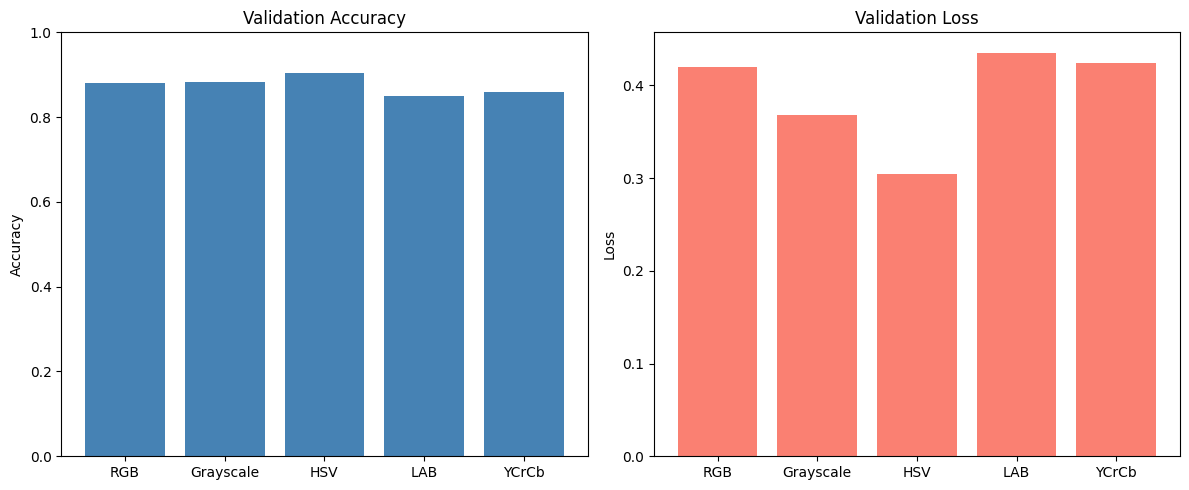

In [39]:
# extract metrics from results
cs_names       = list(results.keys())
accuracies     = [results[cs]['val_accuracy']   for cs in cs_names]
losses         = [results[cs]['val_loss']        for cs in cs_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(cs_names, accuracies, color='steelblue')
axes[0].set_title('Validation Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)

axes[1].bar(cs_names, losses, color='salmon')
axes[1].set_title('Validation Loss')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

### Training time

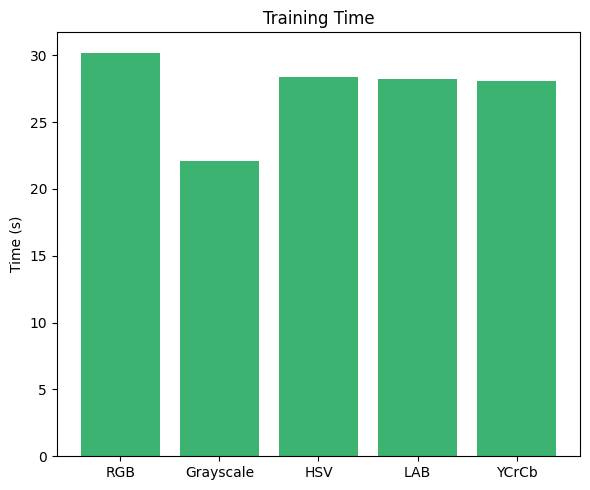

In [40]:
training_times = [results[cs]['training_time'] for cs in cs_names]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(cs_names, training_times, color='mediumseagreen')
ax.set_title('Training Time')
ax.set_ylabel('Time (s)')
plt.tight_layout()
plt.show()

### Training history

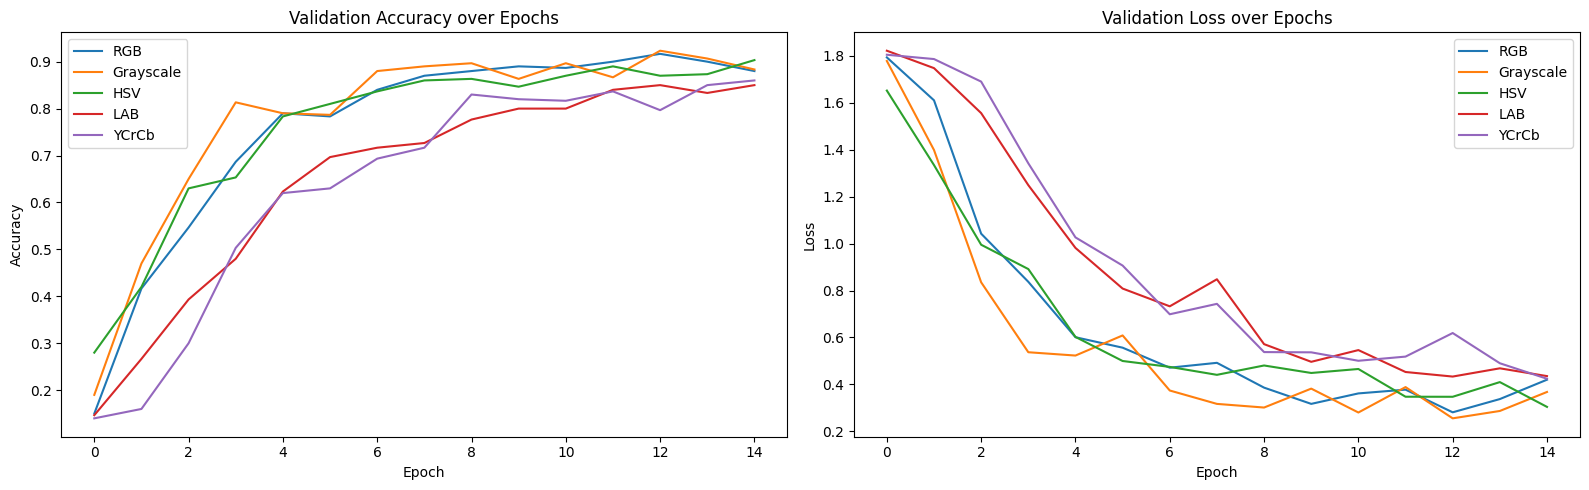

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cs_name, res in results.items():
    axes[0].plot(res['history']['val_accuracy'], label=cs_name)
    axes[1].plot(res['history']['val_loss'],     label=cs_name)

axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validation Loss over Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### Confusion matrices

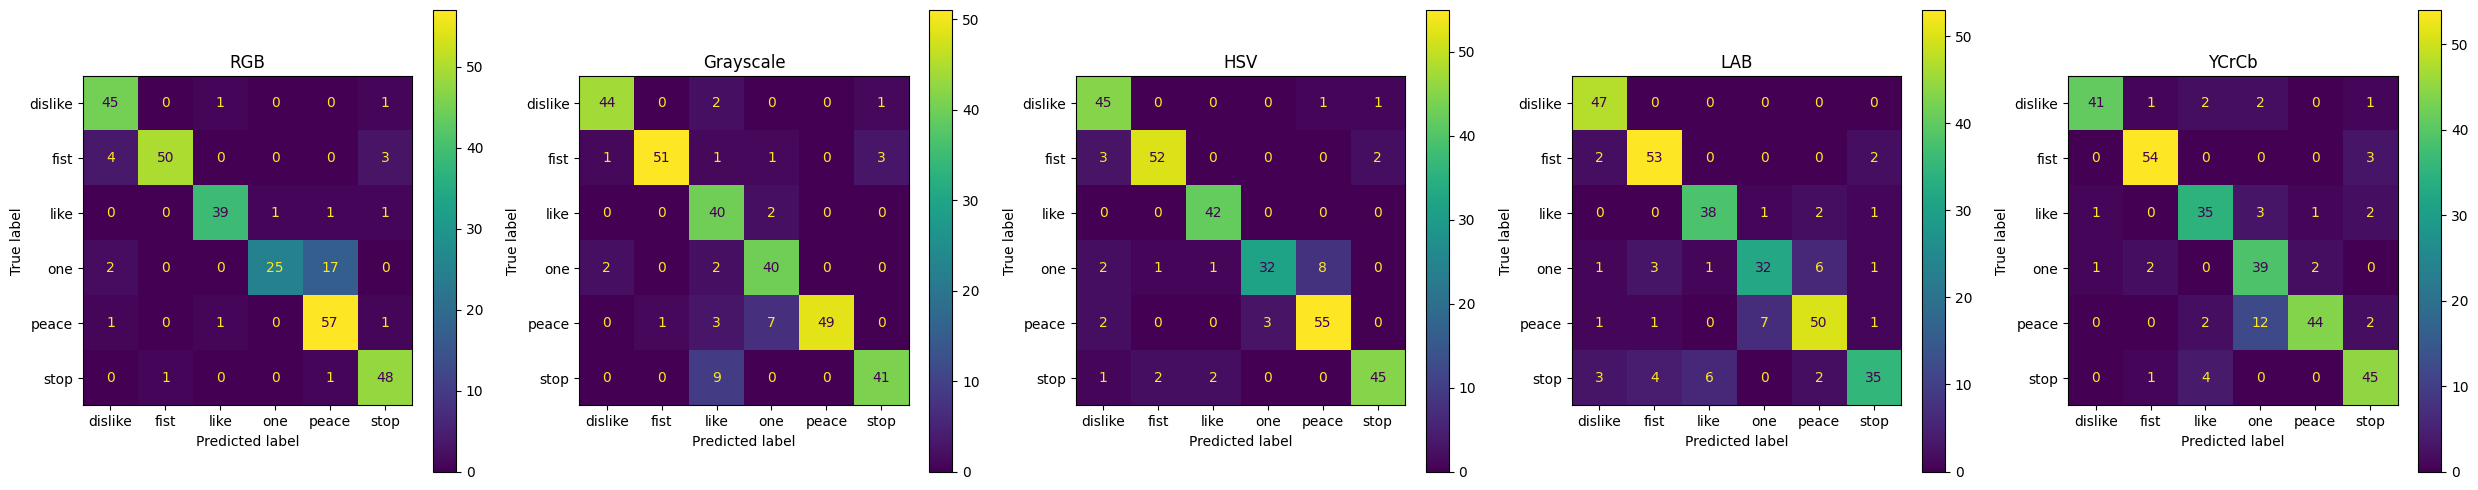

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (cs_name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(res['conf_matrix'], display_labels=label_names).plot(ax=ax)
    ax.set_title(cs_name)

plt.tight_layout()
plt.show()

## Discussion

Before looking at the results, this is what I think:

Grayscale will be the one that takes the least time since it is less data to process

